### Tennis ###

In [74]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:


years = range(2019, 2025)  # From 2020 to 2024, as 2025 is not available yet
base_url = "https://raw.githubusercontent.com/JeffSackmann/tennis_atp/refs/heads/master/atp_matches_{}.csv"

# Loop through years, read each CSV into a list, which will then be concatenated
dfs = []
for year in years:
    url = base_url.format(year) # adding the year to the url
    df_year = pd.read_csv(url)
    df_year['year'] = year  # Adding a year column, as datasets come without one
    dfs.append(df_year)

tennis = pd.concat(dfs)

In [4]:
tennis.columns
tennis.shape

(15980, 50)

In [5]:
### Filter by bigger tournaments
tennis = tennis[tennis["tourney_level"].isin(['G', 'M', 'A'])] # Grand Slams, Masters and other tour level events
tennis.columns

Index(['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level',
       'tourney_date', 'match_num', 'winner_id', 'winner_seed', 'winner_entry',
       'winner_name', 'winner_hand', 'winner_ht', 'winner_ioc', 'winner_age',
       'loser_id', 'loser_seed', 'loser_entry', 'loser_name', 'loser_hand',
       'loser_ht', 'loser_ioc', 'loser_age', 'score', 'best_of', 'round',
       'minutes', 'w_ace', 'w_df', 'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon',
       'w_SvGms', 'w_bpSaved', 'w_bpFaced', 'l_ace', 'l_df', 'l_svpt',
       'l_1stIn', 'l_1stWon', 'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced',
       'winner_rank', 'winner_rank_points', 'loser_rank', 'loser_rank_points',
       'year'],
      dtype='object')

In [6]:
# Data Cleaning
# Tourney Name column has some tournaments written differently
tennis["tourney_name"] = (tennis["tourney_name"]
                          .str.title() # Proper casing
                          .str.replace(".", "") # Avoid sames tournaments spelt differently
                          .str.replace("-", " ")) 
tennis["tourney_name"].sort_values().unique() # quick check

array(['Acapulco', 'Adelaide', 'Adelaide 1', 'Adelaide 2', 'Almaty',
       'Antalya', 'Antwerp', 'Astana', 'Atlanta', 'Atp Cup',
       'Atp Rio De Janeiro', 'Auckland', 'Australian Open', 'Banja Luka',
       'Barcelona', 'Basel', 'Bastad', 'Beijing', 'Belgrade', 'Belgrade ',
       'Belgrade 2', 'Brisbane', 'Bucharest', 'Budapest', 'Buenos Aires',
       'Cagliari', 'Canada Masters', 'Chengdu', 'Cincinnati Masters',
       'Cologne 1', 'Cologne 2', 'Cordoba', 'Dallas', 'Delray Beach',
       'Doha', 'Dubai', 'Eastbourne', 'Estoril', 'Florence', 'Geneva',
       'Gijon', 'Great Ocean Road Open', 'Gstaad', 'Halle', 'Hamburg',
       'Hangzhou', 'Hong Kong', 'Houston', 'Indian Wells Masters',
       'Kitzbuhel', 'Laver Cup', 'Los Cabos', 'Lyon', 'Madrid Masters',
       'Mallorca', 'Marbella', 'Marrakech', 'Marseille', 'Melbourne',
       'Metz', 'Miami Masters', 'Monte Carlo Masters', 'Montpellier',
       'Moscow', 'Munich', 'Murray River Open', 'Naples', 'New York',
       'Newport'

In [7]:
## Check to see how many unique tournament there are
tennis["tourney_id"].str.split("-").str[1:].apply("".join).nunique() # The first part of the ID is the year, hence the split
tennis["turney_id_no_year"] = tennis["tourney_id"].str.split("-").str[1:].apply("".join)

## Check that every tournament name should have one unique ID
tennis.loc[:, ["tourney_name", "turney_id_no_year"]].groupby("tourney_name").nunique().query("turney_id_no_year > 1") # There are some with 2 IDs

,turney_id_no_year
tourney_name,
Acapulco,2
Adelaide,2
Adelaide 1,2
Adelaide 2,2
Antalya,2
Beijing,2
Belgrade,2
Brisbane,2
Cincinnati Masters,2


In [8]:
## Check Player Names
tennis.loc[tennis["winner_name"].str.startswith("L"), "winner_name"].sort_values().unique()

# No incorrectly inputted names in source data

array(['Laslo Djere', 'Leandro Riedi', 'Learner Tien', 'Leo Borg',
       'Leonardo Mayer', 'Li Tu', 'Liam Broady', 'Lloyd Harris',
       'Lorenzo Giustino', 'Lorenzo Musetti', 'Lorenzo Sonego',
       'Luca Nardi', 'Luca Van Assche', 'Lucas Pouille',
       'Luciano Darderi', 'Lukas Klein', 'Lukas Lacko', 'Lukas Neumayer',
       'Lukas Rosol'], dtype=object)

In [9]:
## New dataframe with players and year as grain (instead of match)

# Player names and number of won and lost matches
tennis_winners = tennis.loc[:, ["winner_name","year"]].groupby("year").value_counts().reset_index()
tennis_winners.columns = ["Year", "Player", "Number_of_wins"]
tennis_losers = tennis.loc[:, ["loser_name","year"]].groupby("year").value_counts().reset_index()
tennis_losers.columns = ["Year", "Player", "Number_of_loses"]


# Player heights
tennis_winners.query("Number_of_wins == 0") # No results, all players have won at some point

tennis_heights = (tennis
                  .loc[:, ["winner_name", "winner_ht"]]
                  .rename(columns = {"winner_name" : "Player", "winner_ht":"height"})
                  .drop_duplicates()) # No need to get loser_ht
##

tennis_players = tennis_winners.merge(tennis_losers, how = "inner", on = ["Player", "Year"])
tennis_players = tennis_players.merge(tennis_heights, how = 'left', on = "Player")
tennis_players["W/L"] = round(tennis_players["Number_of_wins"] / tennis_players["Number_of_loses"], 2)
tennis_players["Number_of_matches"] = tennis_players["Number_of_loses"] + tennis_players["Number_of_wins"]

In [10]:
# Some tennis KPIs!!!

# Total number of wins by player
print(tennis_players
      .groupby("Player")
      .sum("Number_of_wins")
      .loc[:, ["Number_of_wins"]]
      .sort_values("Number_of_wins", ascending= False)
      .rename(columns = {"Number_of_wins" : "Number of wins"})
      .head(15))

                       Number of wins
Player                               
Daniil Medvedev                   290
Stefanos Tsitsipas                282
Andrey Rublev                     272
Alexander Zverev                  267
Novak Djokovic                    265
Jannik Sinner                     246
Casper Ruud                       220
Taylor Fritz                      219
Alex De Minaur                    204
Hubert Hurkacz                    202
Carlos Alcaraz                    198
Felix Auger Aliassime             196
Karen Khachanov                   190
Cameron Norrie                    183
Grigor Dimitrov                   180


In [11]:
# Win/Lose ratio by player
print(tennis_players
      .groupby("Player")
      .mean("W/L")
      .round(2)
      .loc[:, ["W/L"]]
      .sort_values("W/L", ascending= False)
      .rename(columns = {"W/L" : "Win Lose Ratio"})
      .head(15))

                    Win Lose Ratio
Player                            
Novak Djokovic                7.45
Roger Federer                 4.23
Rafael Nadal                  4.02
Carlos Alcaraz                3.48
Jannik Sinner                 3.41
Daniil Medvedev               3.16
Renzo Olivo                   3.00
Alexander Zverev              2.76
Andrey Rublev                 2.67
Stefanos Tsitsipas            2.37
Matteo Berrettini             2.10
Casper Ruud                   2.02
Antoine Bellier               2.00
Attila Balazs                 2.00
Roberto Quiroz                2.00


C:\Users\willi\AppData\Local\Temp\ipykernel_9276\1323072482.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_win_rate = tennis_players.groupby("height_bin")["W/L"].mean().reset_index()


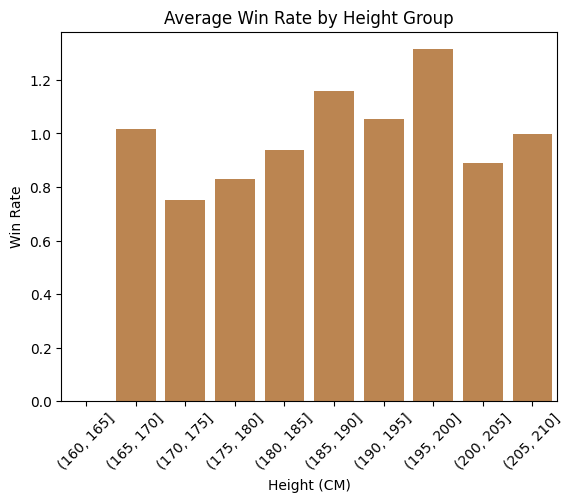

In [12]:
## Line plot, height and win lose ratio
tennis_players["height_bin"] = pd.cut(tennis_players["height"], bins=range(160, 211, 5))
avg_win_rate = tennis_players.groupby("height_bin")["W/L"].mean().reset_index()


sns.barplot(data=avg_win_rate, x="height_bin", y="W/L",color = "peru")
plt.xticks(rotation=45)
plt.title("Average Win Rate by Height Group")
plt.ylabel("Win Rate")
plt.xlabel("Height (CM)")
plt.show()
# Win Rate seems to be larger from 195 to 200 cm, although no statistical tests have been done yet

In [13]:
## New dataframe with players and surface as grain (instead of match)

# Player names and number of won and lost matches
tennis_winners = tennis.loc[:, ["winner_name","surface"]].groupby("surface").value_counts().reset_index()
tennis_winners.columns = ["surface", "Player", "Number_of_wins"]
tennis_losers = tennis.loc[:, ["loser_name","surface"]].groupby("surface").value_counts().reset_index()
tennis_losers.columns = ["surface", "Player", "Number_of_loses"]


# Player heights
tennis_winners.query("Number_of_wins == 0") # No results, all players have won at some point

tennis_heights = (tennis
                  .loc[:, ["winner_name", "winner_ht"]]
                  .rename(columns = {"winner_name" : "Player", "winner_ht":"height"})
                  .drop_duplicates()) # No need to get loser_ht
##

tennis_players = tennis_winners.merge(tennis_losers, how = "inner", on = ["Player", "surface"])
tennis_players = tennis_players.merge(tennis_heights, how = 'left', on = "Player")
tennis_players["W/L"] = round(tennis_players["Number_of_wins"] / tennis_players["Number_of_loses"], 2)
tennis_players["Number_of_matches"] = tennis_players["Number_of_loses"] + tennis_players["Number_of_wins"]

C:\Users\willi\AppData\Local\Temp\ipykernel_9276\1885295381.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_win_rate = tennis_players.groupby(["height_bin", "surface"])["W/L"].mean().reset_index()


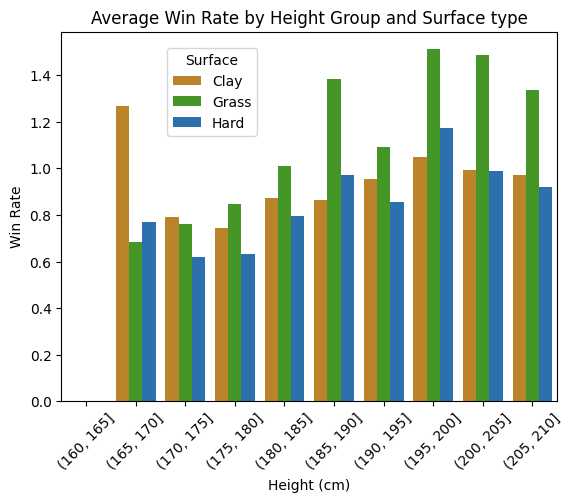

In [39]:
tennis_players["height_bin"] = pd.cut(tennis_players["height"], bins=range(160, 211, 5))

avg_win_rate = tennis_players.groupby(["height_bin", "surface"])["W/L"].mean().reset_index()

hex = sns.color_palette(["#d38913", "#3ba814","#1671c4"])

sns.barplot(data=avg_win_rate, x="height_bin", y="W/L", hue = "surface", palette= hex)
plt.xticks(rotation=45)
plt.title("Average Win Rate by Height Group and Surface type")
plt.ylabel("Win Rate")
plt.xlabel("Height (cm)")
plt.legend(title = "Surface",   bbox_to_anchor=(0.2,0.7)) ##bbox_to_anchor to specify legend location
plt.show()
# Win Rate seems to be larger from 195 to 200 cm, although no statistical tests have been done yet

In [140]:
tennis_grand_slam =  tennis[(tennis["tourney_level"] == "G") & (tennis["round"] == "F") ]
## Grand Slams Wins from 2020 to 2024 by player
tennis_grand_slam_wins = (tennis_grand_slam
                            .loc[:, ["winner_name"]]
                            .value_counts()
                            .reset_index()
      )

tennis_grand_slam_wins.columns = ["Winner Name", "Grand Slam Victories"]

print(tennis_grand_slam_wins)

       Winner Name  Grand Slam Victories
0   Novak Djokovic                    10
1     Rafael Nadal                     5
2   Carlos Alcaraz                     4
3    Jannik Sinner                     2
4  Daniil Medvedev                     1
5    Dominic Thiem                     1


In [83]:
list(tennis_grand_slam["tourney_name"].unique())

['Australian Open', 'Roland Garros', 'Wimbledon', 'Us Open']

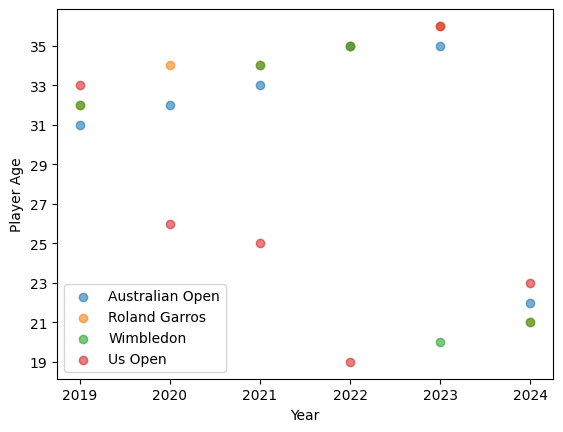

In [92]:
tournaments = list(tennis_grand_slam["tourney_name"].unique())


for tournament in tournaments:
    tennis_grand_slam_filtered = tennis_grand_slam[tennis_grand_slam["tourney_name"] == tournament]
    plt.scatter(tennis_grand_slam_filtered["year"],
                tennis_grand_slam_filtered["winner_age"], 
                label = tournament,
                alpha= 0.6)

plt.yticks(
    ticks=range(tennis_grand_slam["winner_age"].min(), tennis_grand_slam["winner_age"].max()+1, 2),
    labels=range(tennis_grand_slam["winner_age"].min(), tennis_grand_slam["winner_age"].max()+1, 2)
)
plt.xlabel("Year")
plt.ylabel("Player Age")
plt.legend()
plt.show()

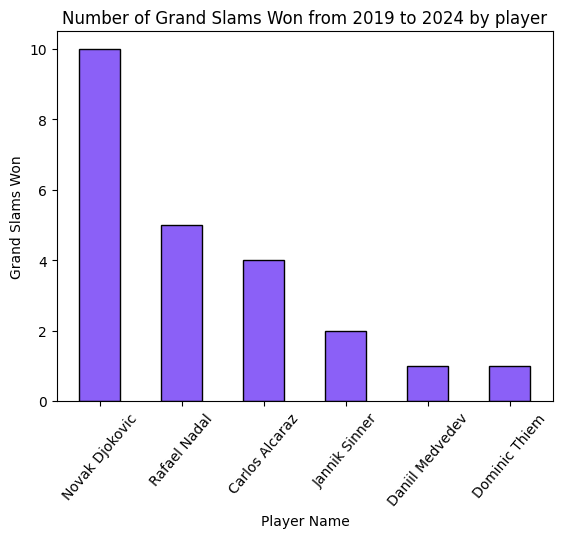

In [ ]:
plt.bar(tennis_grand_slam_wins["Winner Name"],
        tennis_grand_slam_wins["Grand Slam Victories"],
        edgecolor = "Black",
        width= 0.5,
        color = "#8B60F7")
plt.title("Number of Grand Slams won from 2019 to 2024 by player")
plt.xticks(rotation = 50)
plt.xlabel("Player Name")
plt.ylabel("Grand Slams Won")
plt.show()



In [164]:
tennis_grand_slam_wins_surface = (tennis_grand_slam
                            .loc[:, ["winner_name", "surface"]]
                            .value_counts()
                            .reset_index()
      )

tennis_grand_slam_wins_surface.columns = ["Winner Name", "Surface", "Number Of Wins"]
tennis_grand_slam_wins_surface

,Winner Name,Surface,Number Of Wins
0,Novak Djokovic,Hard,5
1,Novak Djokovic,Grass,3
2,Rafael Nadal,Clay,3
3,Jannik Sinner,Hard,2
4,Rafael Nadal,Hard,2
5,Carlos Alcaraz,Grass,2
6,Novak Djokovic,Clay,2
7,Carlos Alcaraz,Hard,1
8,Carlos Alcaraz,Clay,1
9,Daniil Medvedev,Hard,1


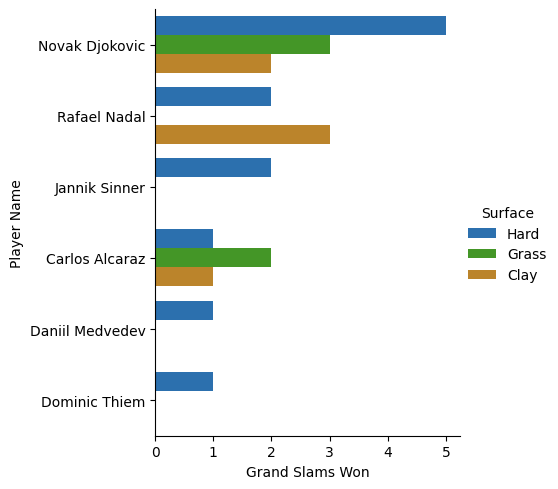

In [ ]:
hex = sns.color_palette(["#1671c4", "#3ba814","#d38913"])

sns.catplot(data=tennis_grand_slam_wins_surface, 
            y = "Winner Name",
            x = "Number Of Wins", 
            kind = "bar",
            hue = "Surface",
            palette=hex)
plt.xlabel("Grand Slams Won")
plt.ylabel("Player Name")
plt.show()


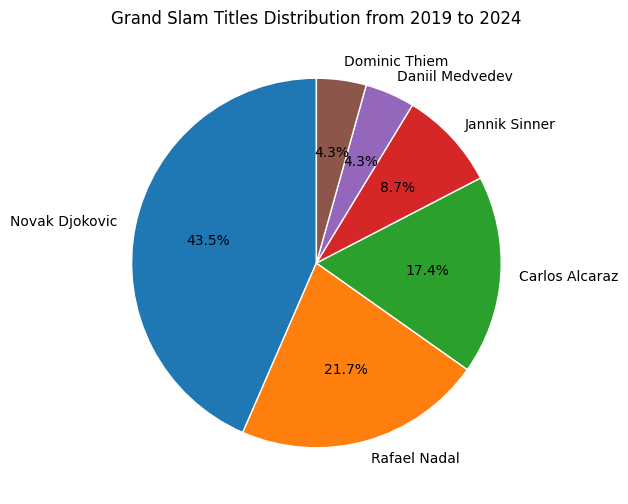

In [144]:

#colors = ["#d62828", "#457b9d", "#f4a261"]

plt.figure(figsize=(6,6))
plt.pie(tennis_grand_slam_wins["Grand Slam Victories"], 
        labels=tennis_grand_slam_wins["Winner Name"], 
        autopct="%1.1f%%", 
        startangle=90, 
        #colors=colors, 
        wedgeprops={'edgecolor':'white'})
plt.title("Grand Slam Titles Distribution from 2019 to 2024")
plt.show()

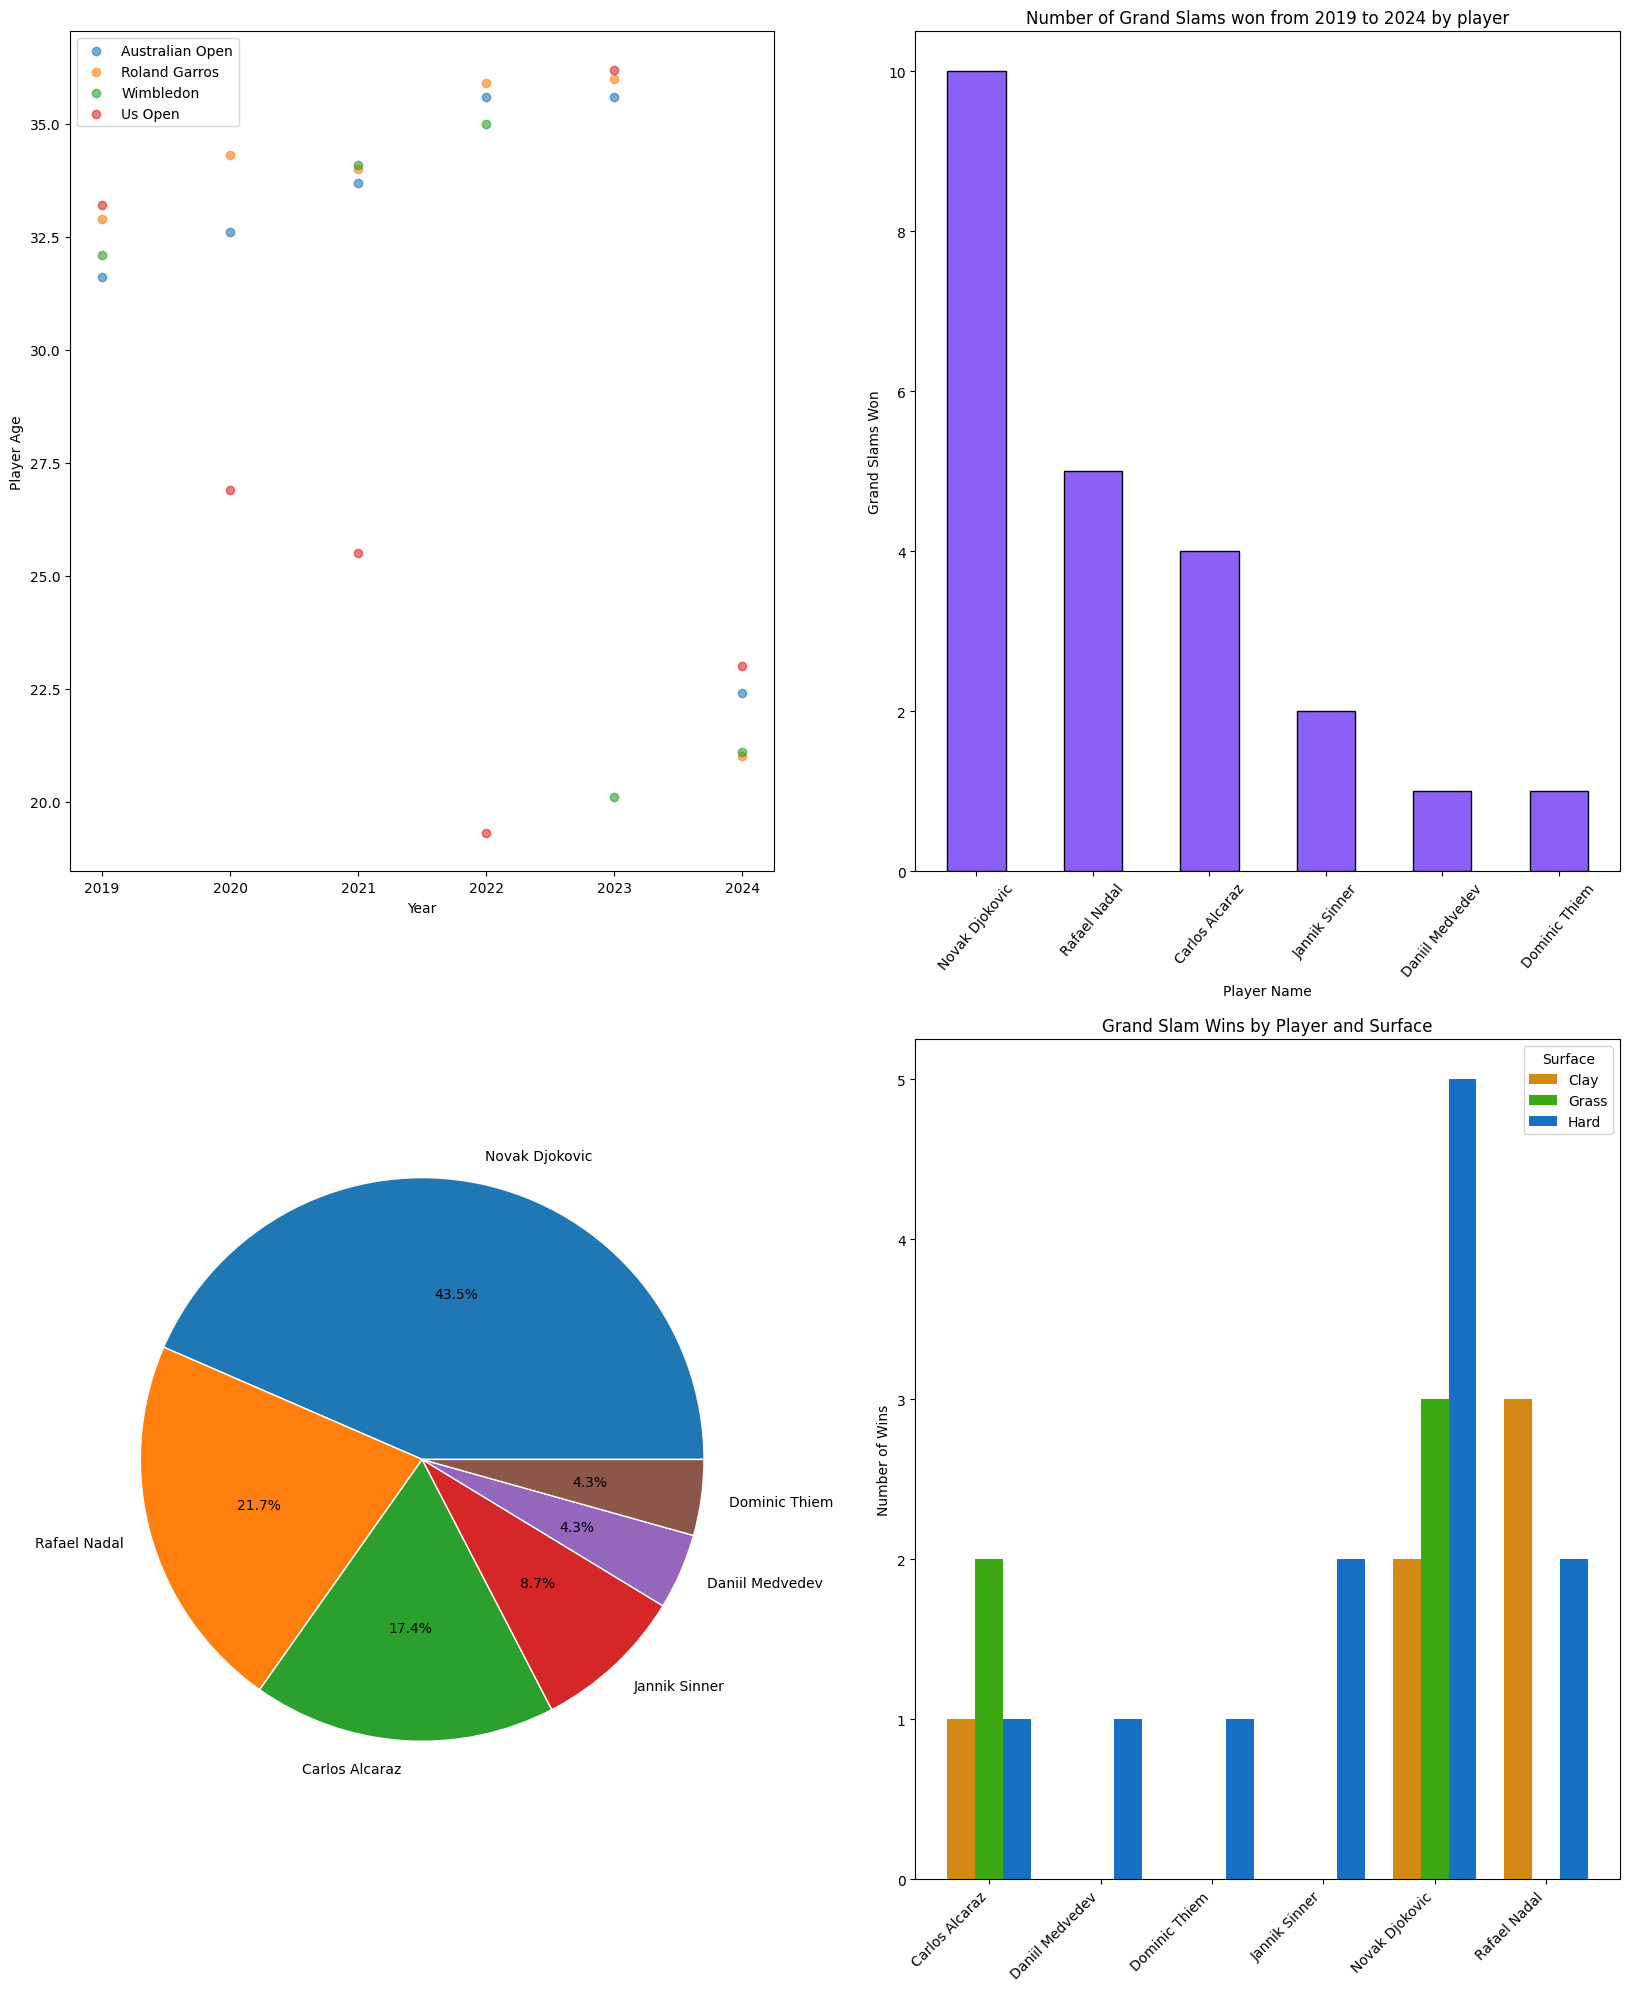

In [168]:
plt.figure(figsize=(20,24))

plt.subplot(2, 2 ,1)

for tournament in tournaments:
    tennis_grand_slam_filtered = tennis_grand_slam[tennis_grand_slam["tourney_name"] == tournament]
    plt.scatter(tennis_grand_slam_filtered["year"],
                tennis_grand_slam_filtered["winner_age"], 
                label = tournament,
                alpha= 0.6)

#plt.yticks(
#    ticks=range(tennis_grand_slam["winner_age"].min(), tennis_grand_slam["winner_age"].max()+1, 2),
   # labels=range(tennis_grand_slam["winner_age"].min(), tennis_grand_slam["winner_age"].max()+1, 2)
#)
plt.xlabel("Year")
plt.ylabel("Player Age")
plt.legend()

plt.subplot(2,2,2)

plt.bar(tennis_grand_slam_wins["Winner Name"],
        tennis_grand_slam_wins["Grand Slam Victories"],
        edgecolor = "Black",
        width= 0.5,
        color = "#8B60F7")
plt.title("Number of Grand Slams won from 2019 to 2024 by player")
plt.xticks(rotation = 50)
plt.xlabel("Player Name")
plt.ylabel("Grand Slams Won")


plt.subplot(2,2,3)
plt.pie(tennis_grand_slam_wins["Grand Slam Victories"], 
        labels=tennis_grand_slam_wins["Winner Name"], 
        autopct="%1.1f%%", 
       # startangle=90, 
        #colors=colors, 
        wedgeprops={'edgecolor':'white'})



plt.subplot(2,2,4)

pivot = tennis_grand_slam_wins_surface.pivot_table(index="Winner Name", columns="Surface", values="Number Of Wins", aggfunc="sum", fill_value=0)

# Setup
players = pivot.index
x = np.arange(len(players))
bar_width = 0.25

# Colors for surfaces
colors = {"Hard": "#1671c4", "Clay": "#d38913", "Grass": "#3ba814"}

for i, surface in enumerate(pivot.columns):
    plt.bar(x + i*bar_width, pivot[surface], width=bar_width, label=surface, color=colors[surface])

# Labels & formatting
plt.xticks(x + bar_width, players, rotation=45, ha="right")
plt.ylabel("Number of Wins")
plt.title("Grand Slam Wins by Player and Surface")
plt.legend(title="Surface")

plt.show()

In [159]:
tennis_grand_slam_wins_surface.columns

Index(['Winner Name', 'Surface', 'Number Of Wins'], dtype='object')